# regrid / landsea 典型场景演示

本 Notebook 面向**用法示例**：

1. **数据预处理**：官方样例 → 六维 meb，并**写回** `test_data/cli_input/`（供 CLI / pytest 使用）
2. **输入数据绘图**：可视化 `cli_input/` 中的源场、目标网格与海陆掩码
3. **典型场景验证**：标准双线性重网格（`bilinear`）、海陆感知最近邻（`nearest-with-mask`）、`bilinear-2`（多 realization）
4. **CLI 应用示例**：调用 `tran_regrid.process` 处理 `cli_input/`；用 Improver `regrid` 命令处理原测试数据写出原 CLI 结果；三者（修改后 CLI / 原方法 CLI / KGO）绘图对比

全量模式验收见 `regrid/test/`（算法输入同样读 `cli_input/`）。


## 1. 环境准备

In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
for path in (PROJECT_ROOT, PROJECT_ROOT / "improver-1.18.7"):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from improver.regrid.landsea import RegridLandSea as OriginalRegridLandSea  # pyright: ignore[reportMissingImports]
from regrid import RegridLandSea

DATA_DIR = (PACKAGE_ROOT / "test_data").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"
print("DATA_DIR =", DATA_DIR)
print("CLI_INPUT_DIR =", CLI_INPUT_DIR)

d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_DIR = D:\workspace\improver\regrid\test_data
CLI_INPUT_DIR = D:\workspace\improver\regrid\test_data\cli_input


## 2. 数据预处理工具

- 经纬：`latitude/longitude` → `lat/lon`
- 投影：`projection_y/x_coordinate` → `lat/lon`，写入 `units="m"` 与 `grid_mapping_attrs`
- `realization` → `member`
- `official_to_meb6d` / `save_meb6d_to_nc`：仅用于写出 `cli_input/`（算法输入）
- KGO / 原 CLI / 原版插件：直接 `iris.load_cube`，经 `to_compare_array` 只比数值
- CLI 输入直接用 `meb.read_griddata_from_nc` 读取


In [2]:
SPATIAL_RENAME = {
    "latitude": "lat",
    "longitude": "lon",
    "projection_y_coordinate": "lat",
    "projection_x_coordinate": "lon",
}



def official_to_meb6d(nc_path: Path, var_name: str | None = None) -> xr.DataArray:
    """官方 nc → 六维 meb（预处理核心）。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    try:
        if var_name is None:
            skip = {"latitude_longitude", "lambert_azimuthal_equal_area"}
            candidates = [
                v
                for v in ds.data_vars
                if v not in skip and not str(v).endswith("_bnds")
            ]
            if not candidates:
                raise ValueError(f"未找到主变量: {nc_path}")
            var_name = candidates[0]
        da = ds[var_name].load()
        gm = da.attrs.get("grid_mapping")
        if isinstance(gm, str) and gm in ds.variables:
            mapping = {}
            for key, value in dict(ds[gm].attrs).items():
                if isinstance(value, np.ndarray):
                    mapping[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping[key] = value.item()
                else:
                    mapping[key] = value
            da.attrs["grid_mapping_attrs"] = json.dumps(mapping, ensure_ascii=False)
    finally:
        ds.close()

    arr = da
    rename = {k: v for k, v in SPATIAL_RENAME.items() if k in arr.dims or k in arr.coords}
    if rename:
        arr = arr.rename(rename)
    if "realization" in arr.dims:
        arr = arr.rename({"realization": "member"})
    for dim in list(arr.dims):
        if dim not in {"lat", "lon", "member"}:
            arr = arr.isel({dim: 0}, drop=True)

    lat_coord = arr.coords["lat"]
    lon_coord = arr.coords["lon"]
    if "projection_y_coordinate" in da.dims or "projection_x_coordinate" in da.dims:
        lat_attrs = dict(lat_coord.attrs)
        lon_attrs = dict(lon_coord.attrs)
        lat_attrs.setdefault("units", "m")
        lon_attrs.setdefault("units", "m")
        lat_attrs.setdefault("standard_name", "projection_y_coordinate")
        lon_attrs.setdefault("standard_name", "projection_x_coordinate")
        lat_coord = xr.DataArray(lat_coord.values, dims=("lat",), attrs=lat_attrs)
        lon_coord = xr.DataArray(lon_coord.values, dims=("lon",), attrs=lon_attrs)

    values = np.asarray(arr.values, dtype=np.float32)
    if values.ndim == 2:
        values = values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :]
        member_coord = np.array([0], dtype=np.int32)
    elif values.ndim == 3 and "member" in arr.dims:
        values = values[:, np.newaxis, np.newaxis, np.newaxis, :, :]
        member_coord = np.asarray(arr.coords["member"].values)
    else:
        raise ValueError(f"暂不支持的数组形状: {values.shape}, dims={arr.dims}")

    attrs = {
        "units": str(arr.attrs.get("units", "1")),
        "model": None,
        "dtime_units": "hour",
        "level_type": "isobaric",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    gma = arr.attrs.get("grid_mapping_attrs")
    if isinstance(gma, str) and gma.strip():
        parsed = json.loads(gma)
        gm_name = str(parsed.get("grid_mapping_name", "")).lower()
        if gm_name and gm_name != "latitude_longitude":
            attrs["grid_mapping_attrs"] = gma

    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": member_coord,
            "level": np.array([0.0], dtype=np.float32),
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": lat_coord,
            "lon": lon_coord,
        },
        name=arr.name,
        attrs=attrs,
    )


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    """写出六维 meb nc，供 CLI / pytest 读取。"""
    normalized = data.copy(deep=True)
    normalized.attrs = {
        k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()
    }
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    var_name = normalized.name if normalized.name else "data"
    normalized.to_dataset(name=var_name).to_netcdf(dst_path)
    print(f"写出: {dst_path}")


def to_compare_array(data) -> np.ndarray:
    if isinstance(data, xr.DataArray):
        arr = np.asarray(data.values, dtype=np.float64)
    elif hasattr(data, "data"):
        arr = np.asarray(data.data, dtype=np.float64)
    else:
        arr = np.asarray(data, dtype=np.float64)
    return np.squeeze(arr)


def summarize_triple(tag: str, migrated, original, kgo, atol: float = 1e-4, rtol: float = 1e-4):
    a = to_compare_array(migrated)
    b = to_compare_array(original)
    c = to_compare_array(kgo)
    if len({a.shape, b.shape, c.shape}) != 1:
        raise ValueError(
            f"{tag}: shape mismatch migrated={a.shape} original={b.shape} kgo={c.shape}"
        )

    print(f"[{tag}] shape={a.shape} atol={atol}")
    all_ok = True
    for x, y, label in (
        (a, c, "migrated vs KGO"),
        (b, c, "original  vs KGO"),
        (a, b, "migrated vs original"),
    ):
        diff = x - y
        finite = np.isfinite(diff)
        abs_max = float(np.nanmax(np.abs(diff))) if finite.any() else np.nan
        close = np.allclose(x, y, atol=atol, rtol=rtol, equal_nan=True)
        print(f"  {label}: max|diff|={abs_max:.6g} allclose={close}")
        all_ok = all_ok and close
    print(f"  => {'PASS' if all_ok else 'DIFF'}\n")
    return all_ok


def plot_triple(
    migrated,
    original,
    kgo,
    title: str,
    member_index: int = 0,
    panel_titles=("修改后方法", "原方法", "KGO"),
):
    panels = []
    for data in (migrated, original, kgo):
        arr = to_compare_array(data)
        if arr.ndim == 3:
            arr = arr[member_index]
        panels.append(arr)

    vmin = min(float(np.nanmin(p)) for p in panels)
    vmax = max(float(np.nanmax(p)) for p in panels)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, data, ttl in zip(axes, panels, panel_titles):
        im = ax.imshow(data, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(ttl)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_input_panels(
    items,
    *,
    ncols: int = 3,
    member_index: int = 0,
    figsize_per=(4.2, 3.6),
):
    """绘制若干输入场（二维 squeeze；三维取 member_index）。

    items: [(data, title, cmap), ...]
    """
    n = len(items)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )
    for i, (data, title, cmap) in enumerate(items):
        ax = axes[i // ncols][i % ncols]
        arr = to_compare_array(data)
        if arr.ndim == 3:
            arr = arr[member_index]
        im = ax.imshow(arr, origin="lower", cmap=cmap)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    plt.tight_layout()
    plt.show()



## 3. 预处理并写出 cli_input

从官方样例转换后写回 `test_data/cli_input/`，供 `python regrid/cli/tran_regrid.py` 与 pytest 使用。

In [3]:
CLI_INPUT_DIR.mkdir(parents=True, exist_ok=True)
CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# (写出文件名, 官方源路径, 可选变量名)
CLI_INPUT_SPECS = [
    ("global_cutout.nc", DATA_DIR / "global_cutout.nc", "air_temperature"),
    ("ukvx_grid.nc", DATA_DIR / "ukvx_grid.nc", "air_temperature"),
    ("glm_landmask.nc", DATA_DIR / "landmask/glm_landmask.nc", "land_binary_mask"),
    ("ukvx_landmask.nc", DATA_DIR / "landmask/ukvx_landmask.nc", "land_binary_mask"),
    ("engl_landmask.nc", DATA_DIR / "landmask/engl_landmask.nc", "land_binary_mask"),
    (
        "global_cutout_multi_realization.nc",
        DATA_DIR / "landmask/global_cutout_multi_realization.nc",
        "air_temperature",
    ),
]

for out_name, src_path, var_name in CLI_INPUT_SPECS:
    meb6d = official_to_meb6d(src_path, var_name)
    save_meb6d_to_nc(meb6d, CLI_INPUT_DIR / out_name)


写出: D:\workspace\improver\regrid\test_data\cli_input\global_cutout.nc
写出: D:\workspace\improver\regrid\test_data\cli_input\ukvx_grid.nc
写出: D:\workspace\improver\regrid\test_data\cli_input\glm_landmask.nc
写出: D:\workspace\improver\regrid\test_data\cli_input\ukvx_landmask.nc
写出: D:\workspace\improver\regrid\test_data\cli_input\engl_landmask.nc
写出: D:\workspace\improver\regrid\test_data\cli_input\global_cutout_multi_realization.nc


## 4. 输入数据绘图

读取第 3 节写出的 `cli_input/`，绘制后续场景将用到的源场、目标网格模板与海陆掩码。
第 5–7 节直接复用此处读入的 meb 变量（`src` / `tgt` / `src_mask` / `tgt_mask` / `src_multi`），不再重复读取。


global_cutout: shape=(1, 1, 1, 1, 75, 71), name=air_temperature, lat.units=degrees_north, projected=False
ukvx_grid: shape=(1, 1, 1, 1, 49, 53), name=air_temperature, lat.units=m, projected=True
glm_landmask: shape=(1, 1, 1, 1, 384, 512), name=land_binary_mask, lat.units=degrees_north, projected=False
ukvx_landmask: shape=(1, 1, 1, 1, 49, 53), name=land_binary_mask, lat.units=m, projected=True
engl_landmask: shape=(1, 1, 1, 1, 192, 256), name=land_binary_mask, lat.units=degrees_north, projected=False
global_cutout_multi: shape=(3, 1, 1, 1, 37, 36), name=air_temperature, lat.units=degrees_north, projected=False


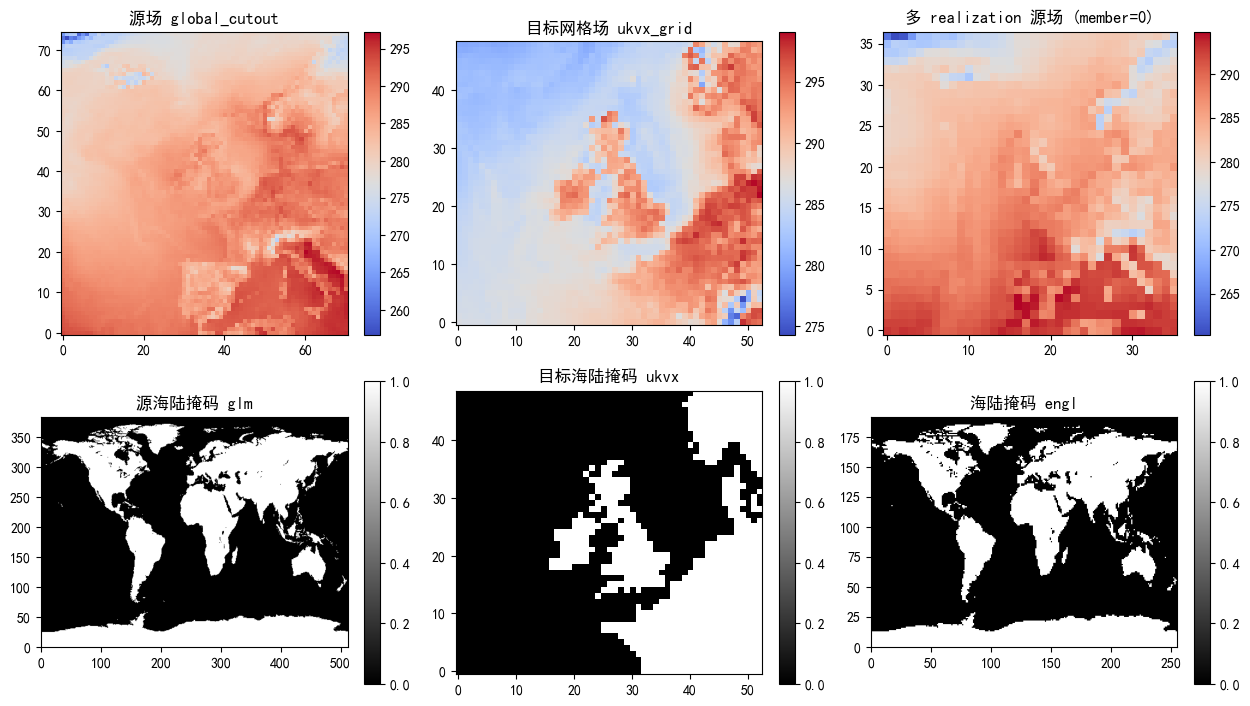

In [4]:
# 从 cli_input 读取（后续场景 / CLI 复用同一套 meb 输入）
src = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "global_cutout.nc"))
tgt = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_grid.nc"))
src_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "glm_landmask.nc"))
tgt_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_landmask.nc"))
engl_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "engl_landmask.nc"))
src_multi = meb.read_griddata_from_nc(
    str(CLI_INPUT_DIR / "global_cutout_multi_realization.nc")
)

for name, da in (
    ("global_cutout", src),
    ("ukvx_grid", tgt),
    ("glm_landmask", src_mask),
    ("ukvx_landmask", tgt_mask),
    ("engl_landmask", engl_mask),
    ("global_cutout_multi", src_multi),
):
    lat_u = da.coords["lat"].attrs.get("units")
    print(
        f"{name}: shape={da.shape}, name={da.name}, "
        f"lat.units={lat_u}, projected={'grid_mapping_attrs' in da.attrs}"
    )

plot_input_panels(
    [
        (src, "源场 global_cutout", "coolwarm"),
        (tgt, "目标网格场 ukvx_grid", "coolwarm"),
        (src_multi, "多 realization 源场 (member=0)", "coolwarm"),
        (src_mask, "源海陆掩码 glm", "gray"),
        (tgt_mask, "目标海陆掩码 ukvx", "gray"),
        (engl_mask, "海陆掩码 engl", "gray"),
    ],
    ncols=3,
)


## 5. 场景一：标准双线性重网格（`bilinear`）

迁移版复用第 4 节的 `src` / `tgt`；原版 / KGO 用 `iris.load_cube` 读官方文件，经 `to_compare_array` 只比数值。


In [5]:
# 原版输入与 KGO（迁移版 src/tgt 已在第 4 节读入）
orig_src = iris.load_cube(str(DATA_DIR / "global_cutout.nc"))
orig_tgt = iris.load_cube(str(DATA_DIR / "ukvx_grid.nc"))
kgo_bilinear = iris.load_cube(str(DATA_DIR / "basic/kgo.nc"), "air_temperature")

print("源场:", src.dims, src.shape, "lat.units=", src.coords["lat"].attrs.get("units"))
print("目标:", tgt.dims, tgt.shape, "lat.units=", tgt.coords["lat"].attrs.get("units"))
print("目标是否投影:", "grid_mapping_attrs" in tgt.attrs)


源场: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 75, 71) lat.units= degrees_north
目标: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 49, 53) lat.units= m
目标是否投影: True


[bilinear] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=6.10352e-05 allclose=True
  original  vs KGO: max|diff|=6.10352e-05 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



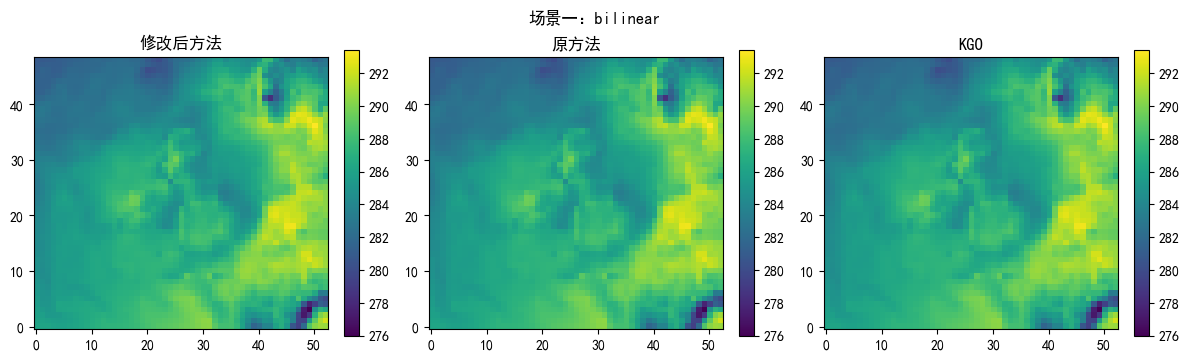

In [6]:
# 修改后方法调用
migrated_bilinear = RegridLandSea(regrid_mode="bilinear")(
    src, tgt, regridded_title="test"
)
# 原方法调用
original_bilinear = OriginalRegridLandSea(regrid_mode="bilinear")(
    orig_src,
    orig_tgt,
    regridded_title="test",
)

summarize_triple("bilinear", migrated_bilinear, original_bilinear, kgo_bilinear)
plot_triple(
    migrated_bilinear,
    original_bilinear,
    kgo_bilinear,
    title="场景一：bilinear",
)


## 6. 场景二：海陆感知最近邻（`nearest-with-mask`）

迁移版复用第 4 节的 `src` / `src_mask` / `tgt_mask`；此处仅读取原版掩码与 KGO。


In [7]:
# 原版掩码与 KGO（迁移版掩码已在第 4 节读入）
orig_src_mask = iris.load_cube(str(DATA_DIR / "landmask/glm_landmask.nc"))
orig_tgt_mask = iris.load_cube(str(DATA_DIR / "landmask/ukvx_landmask.nc"))
kgo_nwm = iris.load_cube(str(DATA_DIR / "landmask/kgo.nc"), "air_temperature")

print("源掩码:", src_mask.shape, src_mask.name)
print("目标掩码:", tgt_mask.shape, tgt_mask.name)


源掩码: (1, 1, 1, 1, 384, 512) land_binary_mask
目标掩码: (1, 1, 1, 1, 49, 53) land_binary_mask


[nearest-with-mask] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



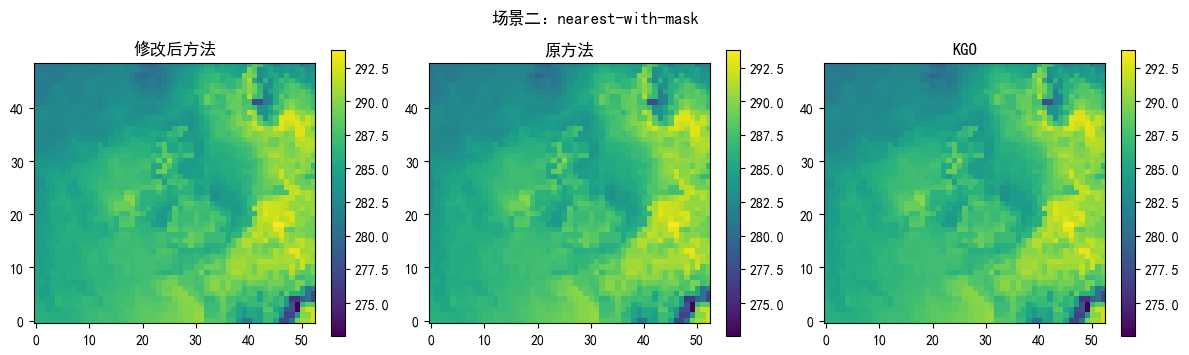

In [8]:
# 修改后方法调用
migrated_nwm = RegridLandSea(
    regrid_mode="nearest-with-mask",
    landmask=src_mask,
    landmask_vicinity=100000,
)(src, tgt_mask, regridded_title="test")
# 原方法调用
original_nwm = OriginalRegridLandSea(
    regrid_mode="nearest-with-mask",
    landmask=orig_src_mask,
    landmask_vicinity=100000,
)(
    orig_src,
    orig_tgt_mask,
    regridded_title="test",
)

summarize_triple("nearest-with-mask", migrated_nwm, original_nwm, kgo_nwm)
plot_triple(
    migrated_nwm,
    original_nwm,
    kgo_nwm,
    title="场景二：nearest-with-mask",
)


## 7. 场景三：新版双线性 + 多 realization（`bilinear-2`）

迁移版复用第 4 节的 `src_multi` / `tgt_mask`；此处仅读取原版多 realization 源场与 KGO。


In [9]:
# 原版多 realization 与 KGO（迁移版 src_multi / tgt_mask 已在第 4 节读入）
orig_src_multi = iris.load_cube(
    str(DATA_DIR / "landmask/global_cutout_multi_realization.nc")
)
kgo_multi = iris.load_cube(str(DATA_DIR / "bilinear_2/kgo_multi_realization.nc"))

print("多 realization 源场:", src_multi.dims, src_multi.shape)
print("member 坐标:", src_multi.coords["member"].values)


多 realization 源场: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (3, 1, 1, 1, 37, 36)
member 坐标: ['0' '1' '2']


[bilinear-2 (multi)] shape=(3, 49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



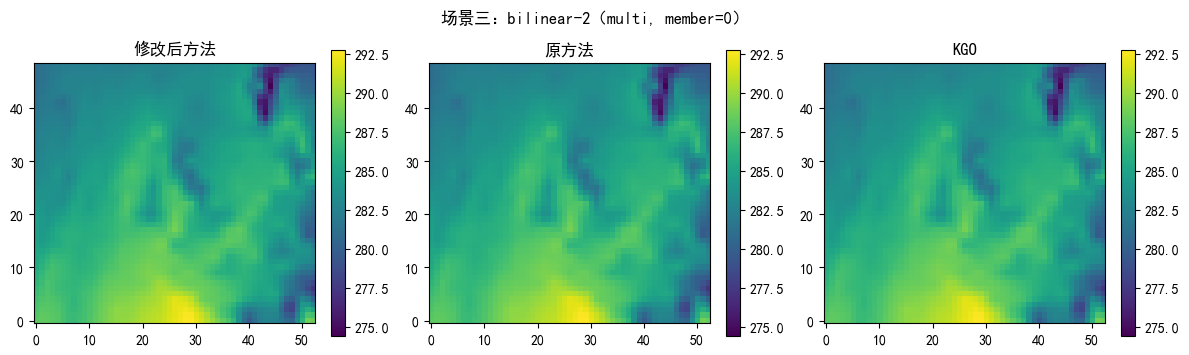

In [10]:
# 修改后方法调用
migrated_multi = RegridLandSea(regrid_mode="bilinear-2")(
    src_multi, tgt_mask, regridded_title="test"
)
# 原方法调用
original_multi = OriginalRegridLandSea(regrid_mode="bilinear-2")(
    orig_src_multi,
    orig_tgt_mask,
    regridded_title="test",
)

summarize_triple("bilinear-2 (multi)", migrated_multi, original_multi, kgo_multi)
plot_triple(
    migrated_multi,
    original_multi,
    kgo_multi,
    title="场景三：bilinear-2（multi, member=0）",
    member_index=0,
)


## 8. CLI 应用示例与结果对比

与第 5–7 节三种模式对应：`8.1 bilinear`、`8.2 nearest-with-mask`、`8.3 bilinear-2`。
对比用的 KGO 变量复用第 5–7 节已读取的 `kgo_*`，请先运行前面场景。

- **修改后 CLI**：调用 `regrid.cli.tran_regrid.process`，输入为第 3 节写出的 `cli_input/`，结果写入 `cli_output/`。
- **原方法 CLI**：通过 `python -m improver.cli regrid`（Improver 库命令）处理**原测试数据**，写出 `cli_output/original_cli_*.nc`。
- **对比**：读取原 CLI 结果与 KGO，三列图为 **修改后CLI | 原方法CLI | KGO**。

终端脚本示例：`python regrid/cli/tran_regrid.py`


In [11]:
import os
import subprocess

from regrid.cli.tran_regrid import process as cli_process

CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def run_original_improver_regrid(
    cube_path: Path,
    target_grid_path: Path,
    output_path: Path,
    *,
    land_sea_mask_path: Path | None = None,
    regrid_mode: str = "bilinear",
    extrapolation_mode: str = "nanmask",
    land_sea_mask_vicinity: float = 25000.0,
    regridded_title: str | None = None,
) -> Path:
    """调用 Improver 库 CLI：`python -m improver.cli regrid ...`，处理原测试数据。"""
    env = os.environ.copy()
    improver_root = str(PROJECT_ROOT / "improver-1.18.7")
    env["PYTHONPATH"] = improver_root + os.pathsep + env.get("PYTHONPATH", "")

    cmd = [
        sys.executable,
        "-m",
        "improver.cli",
        "regrid",
        str(cube_path),
        str(target_grid_path),
    ]
    if land_sea_mask_path is not None:
        cmd.append(str(land_sea_mask_path))
    cmd.extend(
        [
            "--regrid-mode",
            regrid_mode,
            "--extrapolation-mode",
            extrapolation_mode,
            "--land-sea-mask-vicinity",
            str(land_sea_mask_vicinity),
            "--output",
            str(output_path),
        ]
    )
    if regridded_title is not None:
        cmd.extend(["--regridded-title", regridded_title])

    # Improver save_netcdf 在 Windows 上无法用 rename 覆盖已存在文件
    if output_path.exists():
        output_path.unlink()

    print("运行原方法 CLI:")
    print(" ", " ".join(cmd))
    completed = subprocess.run(cmd, env=env, check=True, capture_output=True, text=True)
    if completed.stdout.strip():
        print(completed.stdout)
    if completed.stderr.strip():
        # iris / pkg_resources 等常见告警打到 stderr，仅提示尾部
        print(completed.stderr[-500:])
    print("写出:", output_path, "size=", output_path.stat().st_size)
    return output_path


### 8.1 bilinear

修改后 CLI bilinear 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_bilinear_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\global_cutout.nc D:\workspace\improver\regrid\test_data\ukvx_grid.nc --regrid-mode bilinear --extrapolation-mode nanmask --land-sea-mask-vicinity 25000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear.nc --regridded-title Global Model Forecast on UK 2 km Standard Grid
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear.nc size= 27333
[CLI bilinear] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=6.10352e-05 allclose=True
  original  vs KGO: max|diff|=6.10352e-05 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



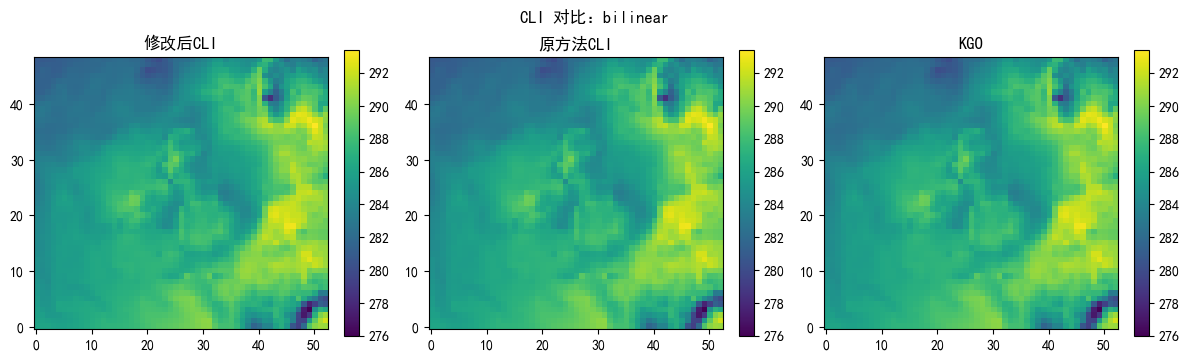

In [12]:
cli_bilinear_out = CLI_OUTPUT_DIR / "cli_bilinear_result.nc"
orig_cli_bilinear_out = CLI_OUTPUT_DIR / "original_cli_bilinear.nc"

# 修改后 CLI
cli_bilinear = cli_process(
    str(CLI_INPUT_DIR / "global_cutout.nc"),
    str(CLI_INPUT_DIR / "ukvx_grid.nc"),
    land_sea_mask_path=None,
    output_path=str(cli_bilinear_out),
    regrid_mode="bilinear",
    regridded_title="Global Model Forecast on UK 2 km Standard Grid",
)
print("修改后 CLI bilinear 写出:", cli_bilinear_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "global_cutout.nc",
    DATA_DIR / "ukvx_grid.nc",
    orig_cli_bilinear_out,
    regrid_mode="bilinear",
    regridded_title="Global Model Forecast on UK 2 km Standard Grid",
)
orig_cli_bilinear = iris.load_cube(str(orig_cli_bilinear_out), "air_temperature")

summarize_triple("CLI bilinear", cli_bilinear, orig_cli_bilinear, kgo_bilinear)
plot_triple(
    cli_bilinear,
    orig_cli_bilinear,
    kgo_bilinear,
    title="CLI 对比：bilinear",
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


### 8.2 nearest-with-mask

修改后 CLI nearest-with-mask 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_nearest_with_mask_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\global_cutout.nc D:\workspace\improver\regrid\test_data\landmask\ukvx_landmask.nc D:\workspace\improver\regrid\test_data\landmask\glm_landmask.nc --regrid-mode nearest-with-mask --extrapolation-mode nanmask --land-sea-mask-vicinity 100000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_nearest_with_mask.nc --regridded-title test
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_nearest_with_mask.nc size= 24667
[CLI nearest-with-mask] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



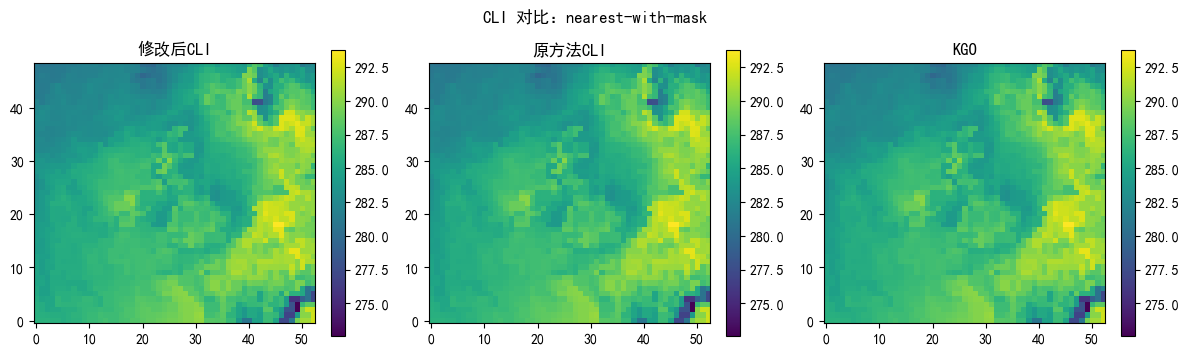

In [13]:
cli_nwm_out = CLI_OUTPUT_DIR / "cli_nearest_with_mask_result.nc"
orig_cli_nwm_out = CLI_OUTPUT_DIR / "original_cli_nearest_with_mask.nc"

# 修改后 CLI
cli_nwm = cli_process(
    str(CLI_INPUT_DIR / "global_cutout.nc"),
    str(CLI_INPUT_DIR / "ukvx_landmask.nc"),
    land_sea_mask_path=str(CLI_INPUT_DIR / "glm_landmask.nc"),
    output_path=str(cli_nwm_out),
    regrid_mode="nearest-with-mask",
    land_sea_mask_vicinity=100000.0,
    regridded_title="test",
)
print("修改后 CLI nearest-with-mask 写出:", cli_nwm_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "global_cutout.nc",
    DATA_DIR / "landmask/ukvx_landmask.nc",
    orig_cli_nwm_out,
    land_sea_mask_path=DATA_DIR / "landmask/glm_landmask.nc",
    regrid_mode="nearest-with-mask",
    land_sea_mask_vicinity=100000.0,
    regridded_title="test",
)
orig_cli_nwm = iris.load_cube(str(orig_cli_nwm_out), "air_temperature")

summarize_triple("CLI nearest-with-mask", cli_nwm, orig_cli_nwm, kgo_nwm)
plot_triple(
    cli_nwm,
    orig_cli_nwm,
    kgo_nwm,
    title="CLI 对比：nearest-with-mask",
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


### 8.3 bilinear-2（多 realization）

修改后 CLI bilinear-2 multi 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_bilinear2_multi_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\landmask\global_cutout_multi_realization.nc D:\workspace\improver\regrid\test_data\landmask\ukvx_landmask.nc --regrid-mode bilinear-2 --extrapolation-mode nanmask --land-sea-mask-vicinity 25000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear2_multi.nc --regridded-title test
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear2_multi.nc size= 40482
[CLI bilinear-2 multi] shape=(3, 49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



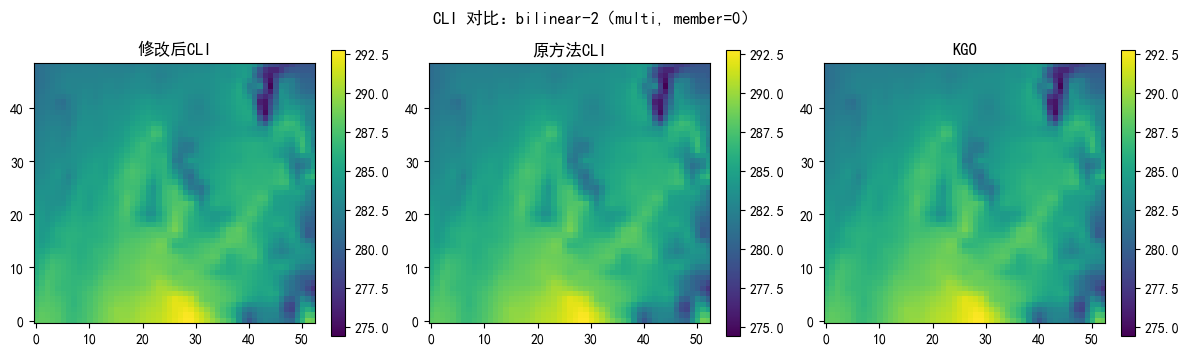

In [14]:
cli_multi_out = CLI_OUTPUT_DIR / "cli_bilinear2_multi_result.nc"
orig_cli_multi_out = CLI_OUTPUT_DIR / "original_cli_bilinear2_multi.nc"

# 修改后 CLI
cli_multi = cli_process(
    str(CLI_INPUT_DIR / "global_cutout_multi_realization.nc"),
    str(CLI_INPUT_DIR / "ukvx_landmask.nc"),
    land_sea_mask_path=None,
    output_path=str(cli_multi_out),
    regrid_mode="bilinear-2",
    regridded_title="test",
)
print("修改后 CLI bilinear-2 multi 写出:", cli_multi_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "landmask/global_cutout_multi_realization.nc",
    DATA_DIR / "landmask/ukvx_landmask.nc",
    orig_cli_multi_out,
    regrid_mode="bilinear-2",
    regridded_title="test",
)
orig_cli_multi = iris.load_cube(str(orig_cli_multi_out))

summarize_triple("CLI bilinear-2 multi", cli_multi, orig_cli_multi, kgo_multi)
plot_triple(
    cli_multi,
    orig_cli_multi,
    kgo_multi,
    title="CLI 对比：bilinear-2（multi, member=0）",
    member_index=0,
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


## 9. 说明

- `cli_input/` 由本 Notebook 第 3 节写出；第 4 节读取并绘图，第 5–7 / 8 节复用其中的 meb 输入。
- CLI 与 pytest 均从 `cli_input/` 读算法输入。
- 修改后 CLI：`python regrid/cli/tran_regrid.py`，或在本 Notebook 第 8 节调用 `tran_regrid.process`。
- 原方法 CLI：`PYTHONPATH=improver-1.18.7 python -m improver.cli regrid ...`（见第 8 节 `run_original_improver_regrid`）。
- 全量测试：`pytest regrid/test -q`
- 原算法插件对比依赖 `improver-1.18.7` 与 `iris`。
